# Gene Window Chromatin Analysis
March 5, 2024

Examine the chromatin data around gene +1s to identify potential technical or biological reasons for enrichment at timepoints 60-70 and 130-140 minutes.

1. Collect MNase-seq data around gene +1s (computed separately)
    - Window of 3 kb
    - Flip if gene is a crick gene
2. Normalize the data based on length distribution.
    - "fix" csv file, removes the chromosome 12 ribosomal DNA reads.
3. Plot as a heatmap of all genes.
    - How do we plot these for all genes for all timepoints?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.raw_chromatin_analysis import ChromatinDataAnalysis

analysis = ChromatinDataAnalysis()

In [3]:
from src.timer import Timer

timer = Timer()
replicate = 1

for chrom in range(1, 17):
    print(f"Chromosome: {chrom}")
    analysis.set_chrom_replicate(chromosome=chrom, replicate=replicate)
    analysis.create_gene_mnase_histogram(timer)


Chromosome: 1
Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr1.h5 from disk.
0/87 - 00:00:01.41
86/87 - 00:00:16.40
Chromosome: 2
Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr2.h5 from disk.
0/390 - 00:00:22.23
100/390 - 00:01:11.02
200/390 - 00:02:03.61
300/390 - 00:02:55.62
389/390 - 00:03:41.48


In [4]:
analysis.all_gene_read_2d_histograms.shape

(5584, 16, 250, 3000)

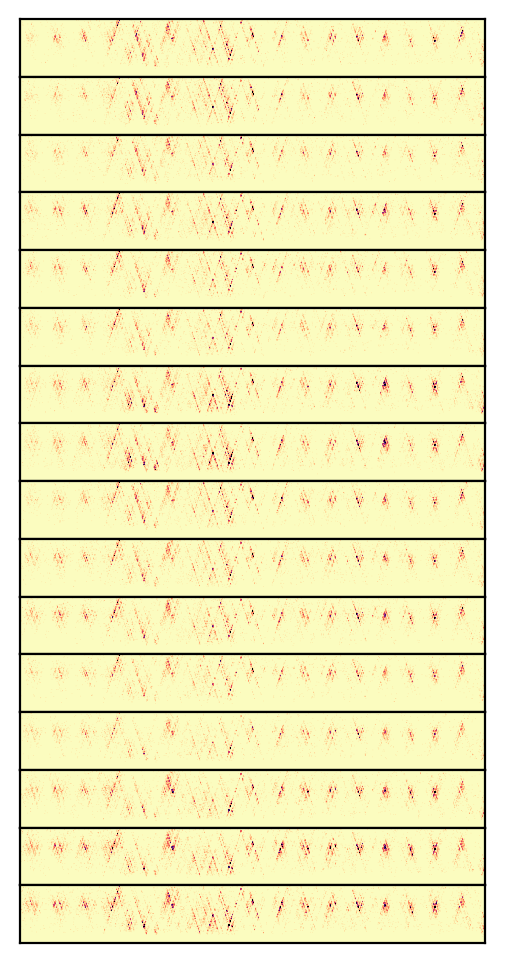

In [5]:
from cc_src.raw_chromatin_analysis import plot_gene_series

plot_gene_series(analysis, analysis.all_gene_read_2d_histograms[380])

In [17]:
gene_2d_hist = analysis.all_gene_read_2d_histograms[0:100]
genes_sum_data = gene_2d_hist.sum(axis=2).sum(axis=2)
genes_sum_data.shape

(100, 16)

0

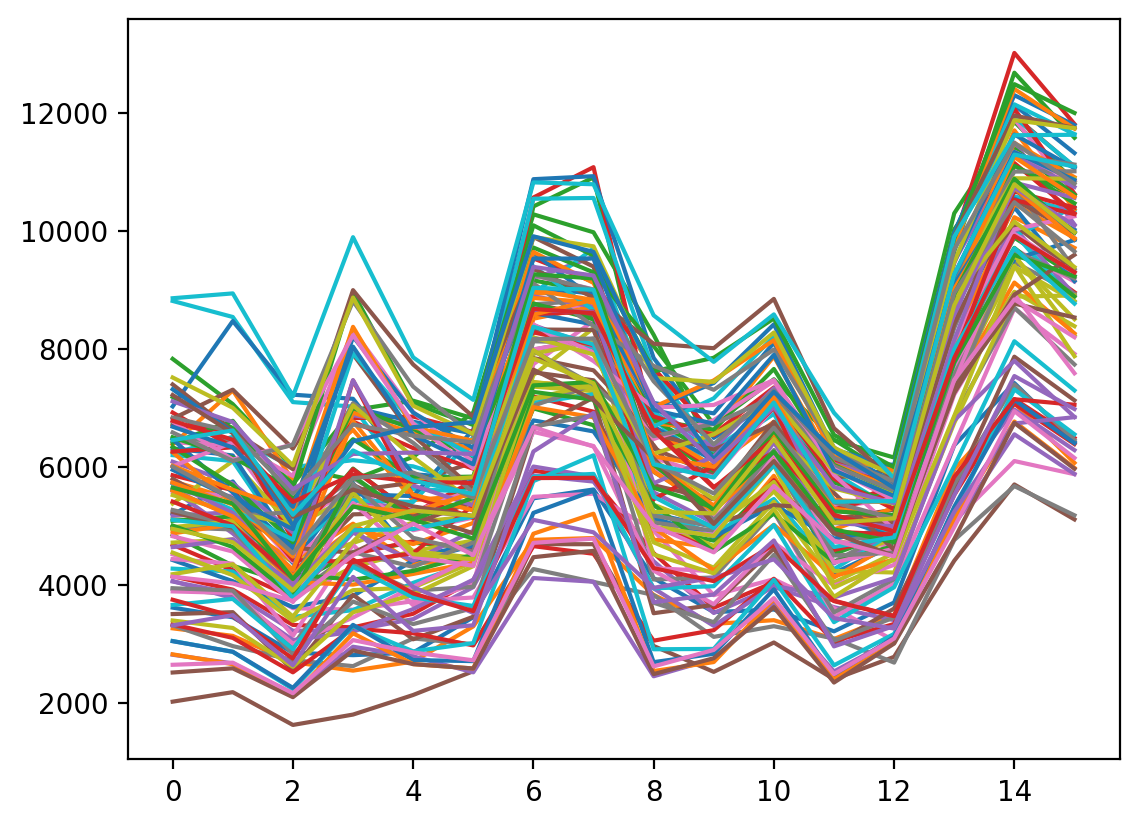

In [18]:
# Not normalized by length distributions
plt.plot(genes_sum_data.T)
0

In [19]:
gene_2d_hist.shape

(100, 16, 250, 3000)

In [29]:
from src.preprocessing import load_scaling_mat
scaling_mat = load_scaling_mat(1)

scaling_mat = scaling_mat.values[:-1, :]
scaling_mat.shape

gene_2d_hist_normalized = gene_2d_hist.copy()

# For each gene
for i in range(gene_2d_hist.shape[0]):

    # For each genomic position
    for j in range(gene_2d_hist.shape[3]):
        
        # Scale the counts by the length scaling matrix
        gene_2d_hist_normalized[i, :, :, j] = gene_2d_hist[i, :, :, j] * scaling_mat.T

In [32]:
genes_sum_data_normalized = gene_2d_hist_normalized.sum(axis=2).sum(axis=2)


0

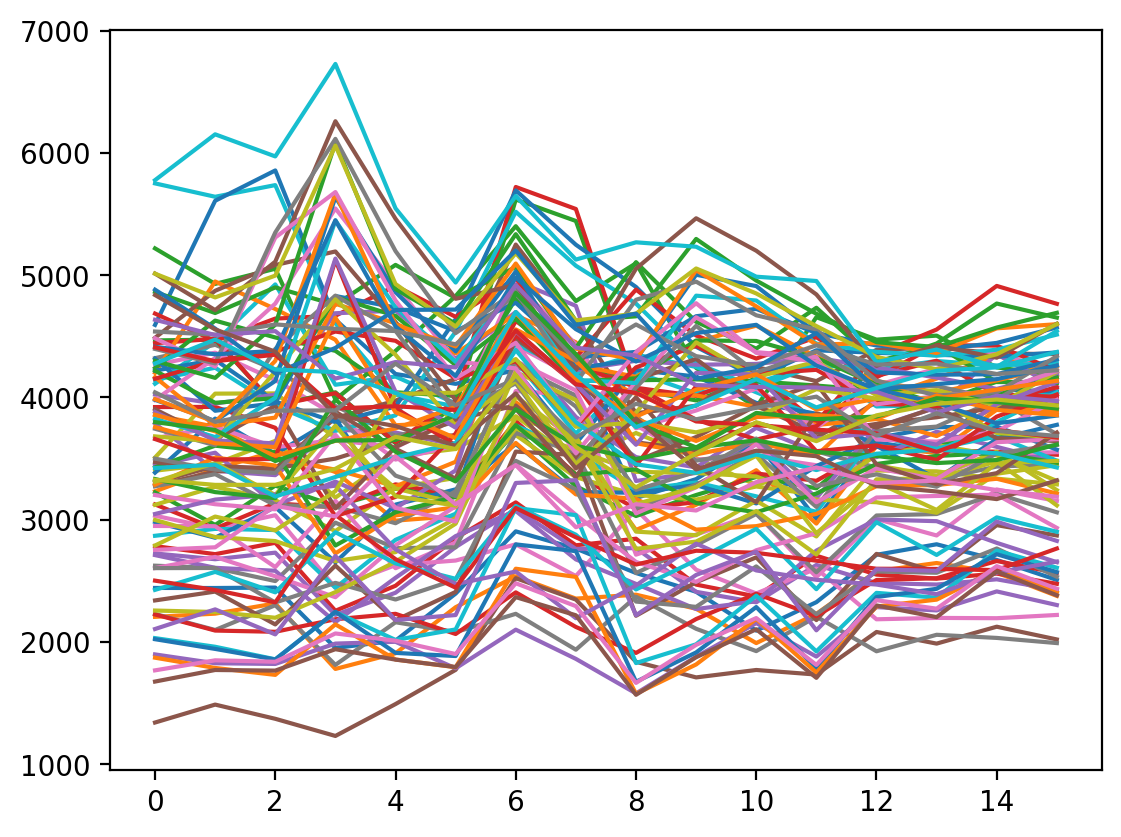

In [33]:
# Not normalized by length distributions
plt.plot(genes_sum_data_normalized.T)
0

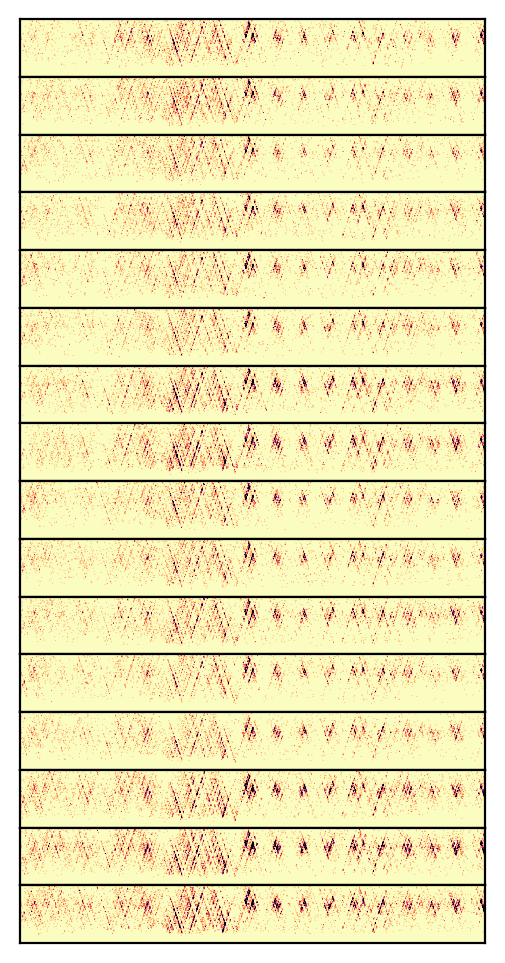

In [40]:
plot_gene_series(analysis, analysis.all_gene_read_2d_histograms[99])

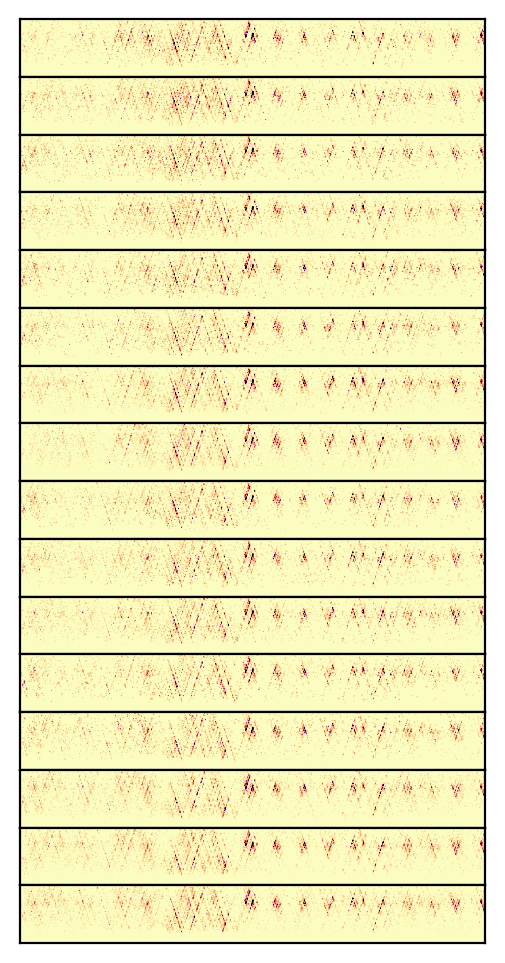

In [41]:
plot_gene_series(analysis, gene_2d_hist_normalized[99])